In [7]:
import pandas as pd
import matplotlib.pyplot as plt

titanic = pd.read_csv('../../data/titanic.csv')
audi    = pd.read_csv('../..//data/02audi.csv')

### EDA
Análisis exploratorio de los datos

**Análisis univariado**: Revisamos solo 1 variable a la vez

- El histograma nos ayuda a ver la distribución de una variable

In [12]:
# Calcular los intervalos para el histograma con numpy, en automatico
import numpy as np
intervalos = np.histogram_bin_edges(audi['price'], bins=10)
print(intervalos)

[  1490.  15841.  30192.  44543.  58894.  73245.  87596. 101947. 116298.
 130649. 145000.]


In [17]:
audi['price'].describe()

count     10668.000000
mean      22896.685039
std       11714.841888
min        1490.000000
25%       15130.750000
50%       20200.000000
75%       27990.000000
max      145000.000000
Name: price, dtype: float64

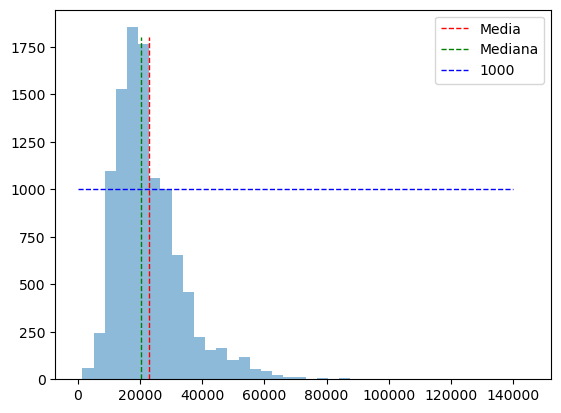

In [26]:
plt.hist(audi['price'], bins=40, alpha=0.5)
plt.vlines(x=audi['price'].mean(), ymin = 0, ymax=1800, color='red', linestyle='dashed', linewidth=1, label='Media')
plt.vlines(x=audi['price'].median(), ymin= 0, ymax=1800, color='green', linestyle='dashed', linewidth=1, label='Mediana')
plt.hlines(1000, xmin=0, xmax=140000, color='blue', linestyle='dashed', linewidth=1, label='1000')
plt.legend()
plt.show()


In [33]:
estadisticas = audi['price'].describe()

print('25%', estadisticas['25%'])
print('50%', estadisticas['50%'])
print('75%', estadisticas['75%'])

# Rango intercuartil
RI = estadisticas['75%'] - estadisticas['25%']
print('Rango intercuartil', RI)

# Limites para detectar outliers
LI = estadisticas['25%'] - 1.5 * RI
LS = estadisticas['75%'] + 1.5 * RI
print('Limite inferior', LI)
print('Limite superior', LS)    

25% 15130.75
50% 20200.0
75% 27990.0
Rango intercuartil 12859.25
Limite inferior -4158.125
Limite superior 47278.875


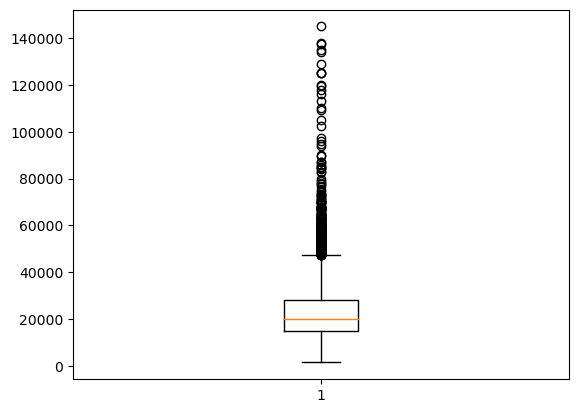

In [28]:
plt.boxplot(audi['price'])
plt.show()

### Métodos de plot desde Pandas

Pandas tiene incorporado a matplotlib por lo que hay métodos que podemos usar para graficar directamente desde Pandas

<Axes: title={'center': 'price'}, xlabel='model'>

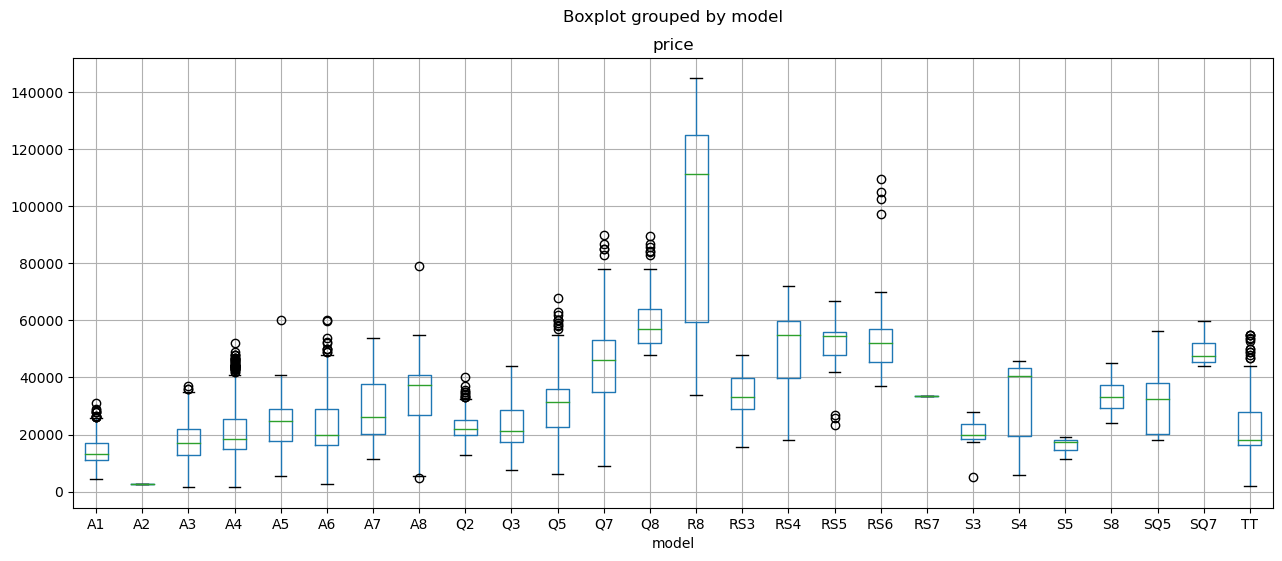

In [39]:
audi.boxplot(column='price', by='model', figsize=(15,6))

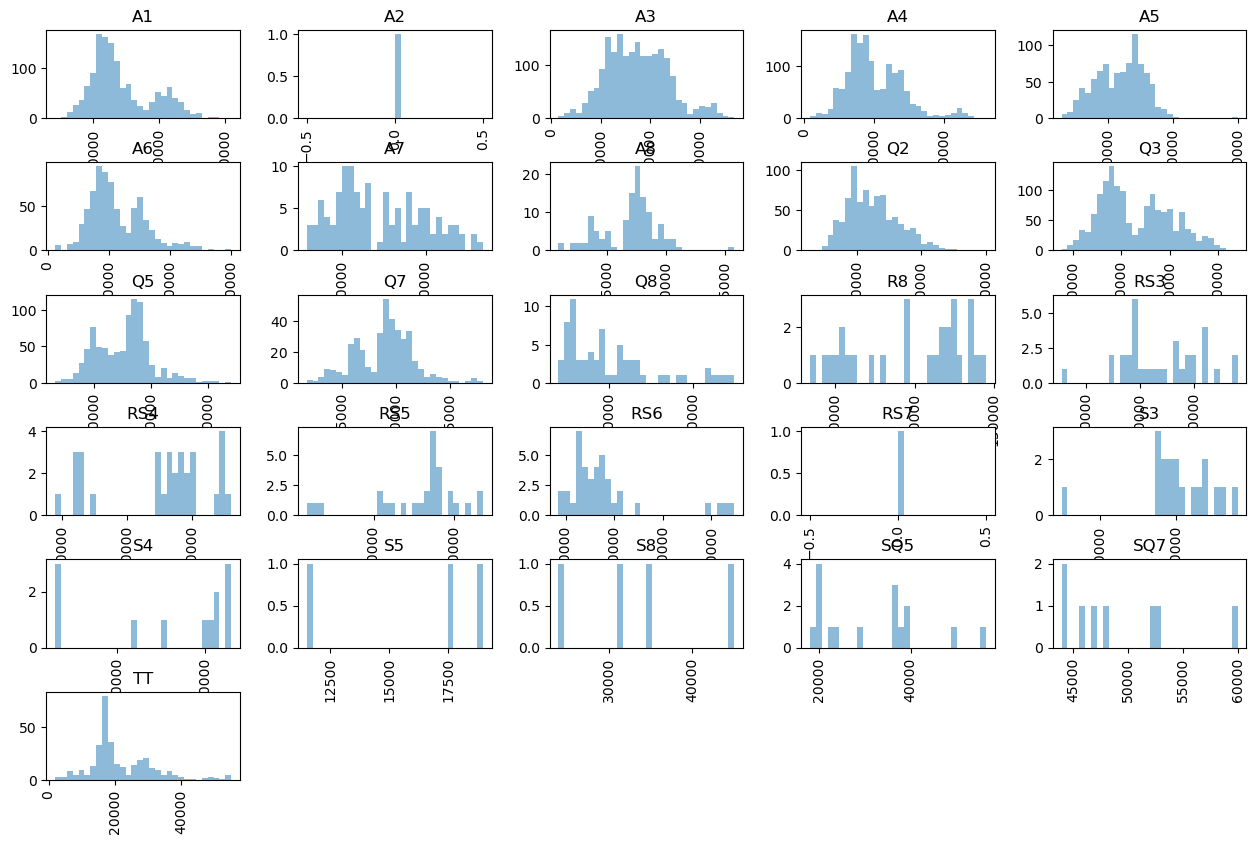

In [41]:
audi.hist(column='price', by='model', figsize=(15,10), bins=30, alpha=0.5)
plt.show()

### Pandas Moderno - Encadenamiento de métodos

Construir transformaciones de Pandas en un pipeline o 'al vuelo'

In [ ]:
audi['price_mxn'] = audi['price'] * 20

In [ ]:
# Función nombrada
def convertir_a_mxn(df):
    df['price_mxn'] = df['price'] * 20
    return df

In [ ]:
# Función anónima
# Funciones de una sola línea
# lambda argumentos: expresión
audi = audi.assign(price_mxn = lambda x: x['price'] * 20)

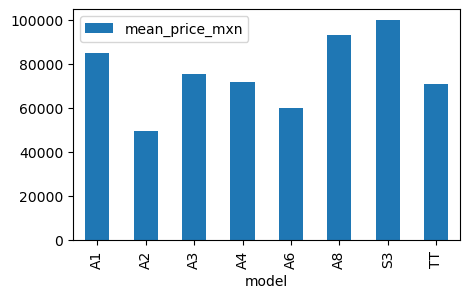

In [61]:
(
    audi
    .query('price < 5000')
    .assign(price_mxn = lambda x: x['price'] * 20) # Función anónima que toma el estado actual del dataframe "x"
    .groupby('model')
    .agg(mean_price_mxn = ('price_mxn', 'mean'))
    .plot(kind='bar', figsize=(5,3))
)

plt.show()

In [65]:
subconjunto = (
    audi
    .query('price < 5000')
)

subconjunto.shape

(60, 10)

### Seaborn

Es la librería de visualización quizá más usada

In [69]:
import seaborn as sns

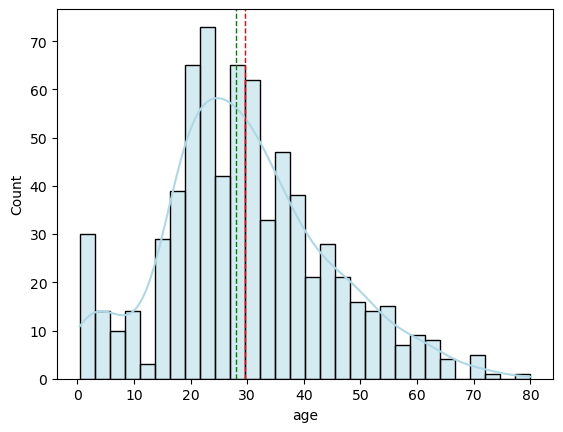

In [77]:
sns.histplot(data=titanic, x='age', bins=30, color='lightblue', kde=True)
plt.axvline(x=titanic['age'].mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(x=titanic['age'].median(), color='green', linestyle='dashed', linewidth=1)
plt.show()

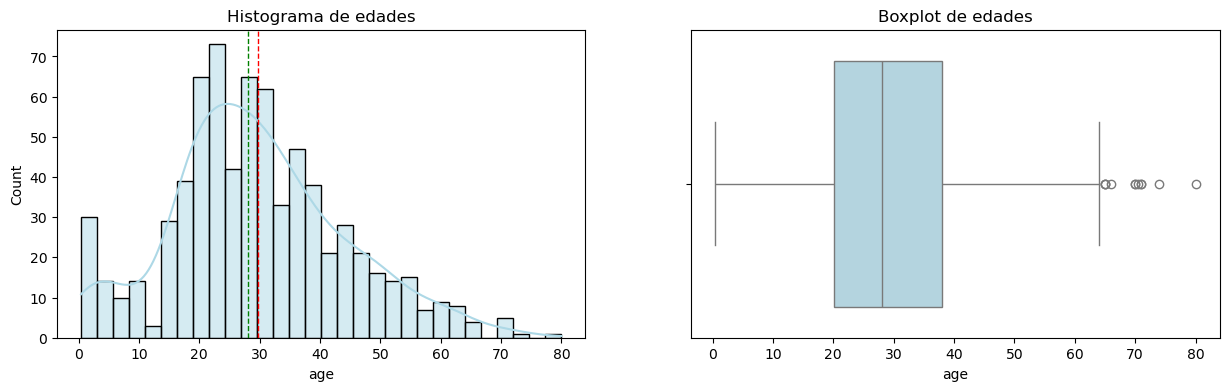

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(15,4)) # 1 fila, 2 columnas

ax[0].set_title('Histograma de edades')
sns.histplot(data=titanic, x='age', bins=30, color='lightblue', kde=True, ax=ax[0])
ax[0].axvline(x=titanic['age'].mean(), color='red', linestyle='dashed', linewidth=1)
ax[0].axvline(x=titanic['age'].median(), color='green', linestyle='dashed', linewidth=1)

ax[1].set_title('Boxplot de edades')
# sns.boxplot(data=titanic, y='age', color='lightblue', ax=ax[1]) # Boxplot vertical
sns.boxplot(data=titanic, x='age', color='lightblue', ax=ax[1]) # Boxplot horizontal

plt.show()

,sex,pclass,mean_age,conteo
0,female,1,34.611765,85
1,female,2,28.722973,74
2,female,3,21.750000,102
3,male,1,41.281386,101
4,male,2,30.740707,99
5,male,3,26.507589,253


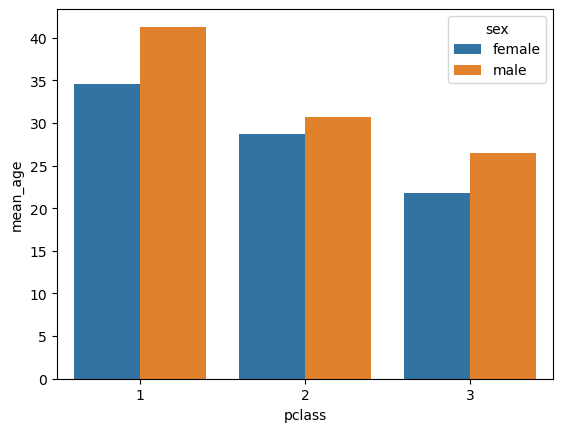

In [108]:
resultado = (
    titanic
    .groupby(['sex', 'pclass'])
    # .agg({'age', 'mean'}) # Forma antigua
    .agg(mean_age = ('age', 'mean'), conteo = ('age', 'count')) # Forma moderna, controlamos el nombre de la nueva columna
    .reset_index()
)

display(resultado)

sns.barplot(data=resultado, x='pclass', y='mean_age', hue='sex')
plt.show()